<a href="https://colab.research.google.com/github/sauravv-kunwar/100-days-of-ML/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ensemble Learning

Ensemble learning is a machine learning paradigm where multiple models (often called "weak learners" or "base estimators") are trained to solve a particular problem.

Key concepts:

*   **Goal**: To improve model stability and accuracy, and reduce variance and bias, compared to a single model.
*   **Diversity**: For an ensemble to be effective, the individual models should be diverse (i.e., make different errors).
*   **Combination**: The predictions from individual models are combined using various strategies (e.g., voting, averaging, weighted averaging).

Common types of ensemble methods:

*   **Bagging (Bootstrap Aggregating)**:
    *   Trains multiple models on different subsets of the training data (sampled with replacement).
    *   Examples: Random Forest (uses decision trees as base learners).
    *   Reduces variance.

*   **Boosting**:
    *   Sequentially builds models where each new model corrects the errors of the previous ones.
    *   Examples: AdaBoost, Gradient Boosting Machines (GBM), XGBoost, LightGBM.
    *   Reduces bias.

*   **Stacking (Stacked Generalization)**:
    *   Trains a meta-learner (or blender) to combine the predictions of several base models.
    *   The base models are trained on the full training data, and their predictions become input features for the meta-learner.

*   **Voting**:
    *   Combines predictions from multiple models using a voting mechanism (e.g., majority vote for classification, averaging for regression).
    *   Can be hard voting (direct predictions) or soft voting (probabilities).

Benefits:

*   Higher accuracy and better generalization.
*   More robust to noise and outliers.
*   Reduced overfitting (especially bagging) and underfitting (especially boosting).

Challenges:

*   Increased computational cost and complexity.
*   Interpretability can be more difficult than with single models.

In [1]:
import sys
!{sys.executable} -m pip install graphviz

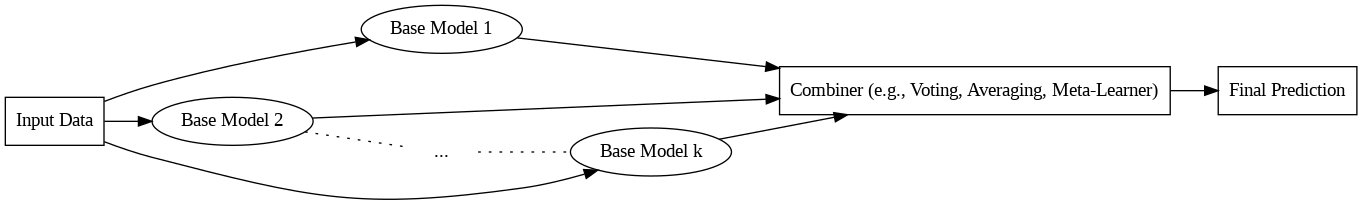

In [2]:
from graphviz import Digraph
from IPython.display import Image

dot = Digraph(comment='Ensemble Learning Concept', graph_attr={'rankdir': 'LR'})

dot.node('Input', 'Input Data', shape='box')
dot.node('BM1', 'Base Model 1', shape='ellipse')
dot.node('BM2', 'Base Model 2', shape='ellipse')
dot.node('BMn', '...', shape='plaintext')
dot.node('BMk', 'Base Model k', shape='ellipse')
dot.node('Combiner', 'Combiner (e.g., Voting, Averaging, Meta-Learner)', shape='box')
dot.node('Output', 'Final Prediction', shape='box')

dot.edge('Input', 'BM1')
dot.edge('Input', 'BM2')
dot.edge('Input', 'BMk')
dot.edge('BM1', 'Combiner')
dot.edge('BM2', 'Combiner')
dot.edge('BMk', 'Combiner')
dot.edge('Combiner', 'Output')

# Add an arrow from BM2 to BMn to show continuation (conceptually)
dot.edge('BM2', 'BMn', style='dotted', arrowhead='none')
dot.edge('BMn', 'BMk', style='dotted', arrowhead='none')

display(Image(dot.render(filename='ensemble_concept', format='png', view=False)))


### Explanation of the Ensemble Learning Visualization:

This diagram conceptually illustrates how ensemble learning works:

*   **Input Data**: The raw data that the ensemble model receives.
*   **Base Model 1, Base Model 2, ..., Base Model k**: These represent individual machine learning models (e.g., decision trees, neural networks) that are trained on the data.
    *   In **Bagging**, these models are often of the same type and trained independently on different subsets of the data.
    *   In **Boosting**, these models are trained sequentially, with each model focusing on correcting errors made by previous models.
*   **Combiner**: This component takes the predictions from all the individual Base Models and combines them into a single, more robust prediction.
    *   This can involve simple methods like **Voting** (for classification) or **Averaging** (for regression).
    *   More complex methods like **Stacking** use another machine learning model (a 'meta-learner') to learn how to best combine the base model predictions.
*   **Final Prediction**: The output of the Combiner, which is intended to be more accurate and generalize better than any single base model's prediction.